In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 9
fig_height = 6
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbWl0aHVubWFuaXZhbm5hbi9wcm9qZWN0cy9iZW5jaG1hcmtpbmdfbG9zc19mdW5jdGlvbnNfZWNnX3JlY29uc3RydWN0aW9uL2Jvb2s='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/usr/lib/python3.12/importlib/_bootstrap.py": 1781873160.0, "/usr/lib/python3.12/importlib/_bootstrap_external.py": 1781873160.0, "/usr/lib/python3.12/zipimport.py": 1781873160.0, "/usr/lib/python3.12/codecs.py": 1781873160.0, "/usr/lib/python3.12/encodings/aliases.py": 1781873160.0, "/usr/lib/python3.12/encodings/__init__.py": 1781873160.0, "/usr/lib/python3.12/encodings/utf_8.py": 1781873160.0, "/usr/lib/python3.12/abc.py": 1781873160.0, "/usr/lib/python3.12/io.py": 1781873160.0, "/usr/lib/python3.12/stat.py": 1781873160.0, "/usr/lib/python3.12/_collections_abc.py": 1781873160.0, "/usr/lib/python3.12/genericpath.py": 1781873160.0, "/usr/lib/python3.12/posixpath.py": 1781873160.0, "/usr/lib/python3.12/os.py": 1781873160.0, "/usr/lib/python3.12/_sitebuiltins.py": 1781873160.0, "/usr/lib/python3.12/__future__.py": 1781873160.0, "/usr/lib/python3.12/warnings.py": 1781873160.0, "/usr/lib/python3.12/importlib/__init__.py": 1781873160.0, "/usr/lib/python3.12/importlib/machinery.py": 17818

In [2]:
#| label: zhejiang-setup
#| code-fold: true
from pathlib import Path
import hashlib
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

REPO = Path("..").resolve()
DATA_ROOT = REPO / "data" / "zhejiang"
ECG_ROOT = DATA_ROOT / "ecg"
LABEL_ROOT = DATA_ROOT / "label"
RESULT_CSV = REPO / "results" / "zhejiang_benchmark" / "zhejiang_delineation_evaluation.csv"

LEADS = ("I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6")

def sha256_file(path, chunk_bytes=1024 * 1024):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_bytes), b""):
            digest.update(chunk)
    return digest.hexdigest()

if not ECG_ROOT.is_dir() or not LABEL_ROOT.is_dir():
    raise FileNotFoundError(
        "The Zhejiang audit requires data/zhejiang/ecg and data/zhejiang/label."
    )

In [3]:
#| label: zhejiang-inventory
#| code-fold: true
signal_files = sorted(ECG_ROOT.glob("*.pkl"))
label_files = sorted(LABEL_ROOT.glob("*.pkl"))

signal_rows = []
for path in signal_files:
    stem = path.stem
    record_id, sep, lead = stem.rpartition("_")
    signal_rows.append({
        "record_id": record_id if sep else stem,
        "lead": lead if sep else "UNPARSED",
        "path": str(path.relative_to(REPO)),
    })

signal_index = pd.DataFrame(signal_rows)
label_ids = {path.stem for path in label_files}
signal_ids = set(signal_index["record_id"])
lead_counts = signal_index.groupby("record_id")["lead"].nunique()

inventory = pd.DataFrame([
    ("Signal files", len(signal_files)),
    ("Label files", len(label_files)),
    ("Unique signal record IDs", len(signal_ids)),
    ("Signal IDs with a label", len(signal_ids & label_ids)),
    ("Signal IDs missing a label", len(signal_ids - label_ids)),
    ("Label IDs missing signals", len(label_ids - signal_ids)),
    ("Records with all 12 named leads", int((lead_counts == 12).sum())),
], columns=["Audit quantity", "Observed value"])
display(inventory)

unexpected_leads = sorted(set(signal_index["lead"]) - set(LEADS))
missing_named_leads = {
    record_id: sorted(set(LEADS) - set(group["lead"]))
    for record_id, group in signal_index.groupby("record_id")
    if set(group["lead"]) != set(LEADS)
}
display(Markdown(
    f"**Pairing verdict:** unexpected lead labels = `{unexpected_leads}`; "
    f"records with a missing or extra named lead set = `{len(missing_named_leads)}`."
))

,Audit quantity,Observed value
0,Signal files,4008
1,Label files,334
2,Unique signal record IDs,334
3,Signal IDs with a label,334
4,Signal IDs missing a label,0
5,Label IDs missing signals,0
6,Records with all 12 named leads,334


**Pairing verdict:** unexpected lead labels = `[]`; records with a missing or extra named lead set = `0`.

In [4]:
#| label: zhejiang-array-audit
#| code-fold: true
signal_audit = []
for path in signal_files:
    with path.open("rb") as handle:
        array = np.asarray(pickle.load(handle))
    signal_audit.append({
        "samples": int(array.size),
        "ndim": int(array.ndim),
        "dtype": str(array.dtype),
        "finite": bool(np.isfinite(array).all()),
    })

mask_audit = []
mask_class_counts = {class_id: 0 for class_id in (0, 1, 2, 3)}
unexpected_mask_values = set()
for path in label_files:
    with path.open("rb") as handle:
        mask = np.asarray(pickle.load(handle))
    values, counts = np.unique(mask, return_counts=True)
    for value, count in zip(values, counts):
        numeric_value = float(value)
        if numeric_value in mask_class_counts:
            mask_class_counts[int(numeric_value)] += int(count)
        else:
            unexpected_mask_values.add(numeric_value)
    mask_audit.append({
        "samples": int(mask.size),
        "ndim": int(mask.ndim),
        "dtype": str(mask.dtype),
        "finite": bool(np.isfinite(mask).all()),
    })

signal_audit = pd.DataFrame(signal_audit)
mask_audit = pd.DataFrame(mask_audit)
array_summary = pd.DataFrame([
    ("Signals", len(signal_audit), sorted(signal_audit["samples"].unique().tolist()),
     sorted(signal_audit["ndim"].unique().tolist()),
     ", ".join(sorted(signal_audit["dtype"].unique())), int((~signal_audit["finite"]).sum())),
    ("Masks", len(mask_audit), sorted(mask_audit["samples"].unique().tolist()),
     sorted(mask_audit["ndim"].unique().tolist()),
     ", ".join(sorted(mask_audit["dtype"].unique())), int((~mask_audit["finite"]).sum())),
], columns=["Object", "Files checked", "Observed lengths", "Observed dimensions", "Dtypes", "Files with non-finite values"])
display(array_summary)

class_table = pd.DataFrame({
    "Mask class": [0, 1, 2, 3],
    "Interpreted region": ["Background", "P wave", "QRS complex", "T wave"],
    "Annotated samples": [mask_class_counts[i] for i in (0, 1, 2, 3)],
})
class_table["Share of all mask samples"] = (
    class_table["Annotated samples"] / class_table["Annotated samples"].sum()
)
display(class_table.style.format({"Share of all mask samples": "{:.2%}"}))
display(Markdown(f"**Unexpected mask values:** `{sorted(unexpected_mask_values)}`"))

,Object,Files checked,Observed lengths,Observed dimensions,Dtypes,Files with non-finite values
0,Signals,4008,[20000],[1],float64,0
1,Masks,334,[20000],[1],float64,0


,Mask class,Interpreted region,Annotated samples,Share of all mask samples
0,0,Background,5546062,83.02%
1,1,P wave,176499,2.64%
2,2,QRS complex,354438,5.31%
3,3,T wave,603001,9.03%


**Unexpected mask values:** `[]`

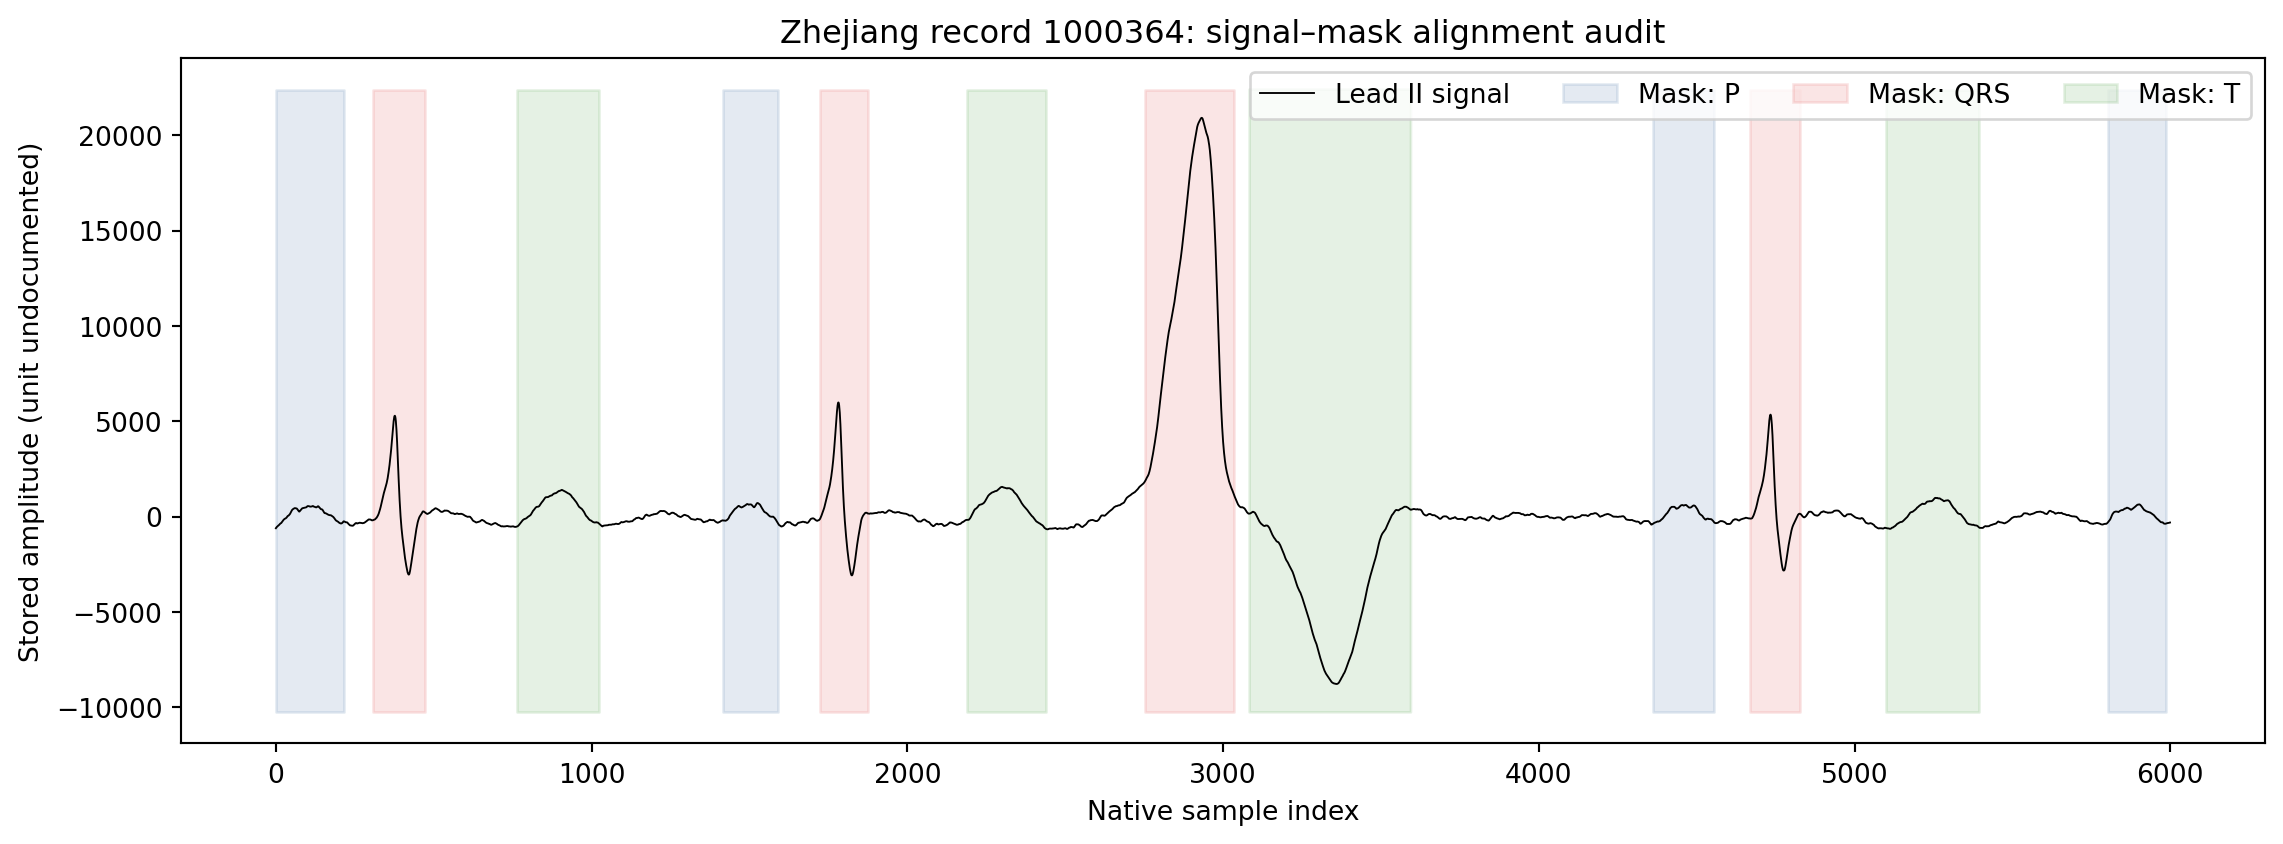

In [5]:
#| label: zhejiang-example
#| fig-cap: A locally stored Lead II signal with its categorical annotation mask. Axis units are intentionally not inferred.
#| code-fold: true
example_id = sorted(signal_ids & label_ids)[0]
with (ECG_ROOT / f"{example_id}_II.pkl").open("rb") as handle:
    example_signal = np.asarray(pickle.load(handle), dtype=float)
with (LABEL_ROOT / f"{example_id}.pkl").open("rb") as handle:
    example_mask = np.asarray(pickle.load(handle))

window = slice(0, min(6000, example_signal.size))
x = np.arange(example_signal.size)[window]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(x, example_signal[window], color="black", linewidth=0.7, label="Lead II signal")
ymin, ymax = ax.get_ylim()
for class_id, label, color in [(1, "P", "#4C78A8"), (2, "QRS", "#E45756"), (3, "T", "#54A24B")]:
    ax.fill_between(x, ymin, ymax, where=example_mask[window] == class_id,
                    color=color, alpha=0.15, label=f"Mask: {label}")
ax.set(xlabel="Native sample index", ylabel="Stored amplitude (unit undocumented)",
       title=f"Zhejiang record {example_id}: signal–mask alignment audit")
ax.legend(ncol=4, loc="upper right")
fig.tight_layout()
plt.show()

In [6]:
#| label: zhejiang-result-status
#| code-fold: true
if RESULT_CSV.exists():
    current_results = pd.read_csv(RESULT_CSV)
    display(current_results)
    model_rows = current_results.loc[current_results["model_id"] != "ground_truth_ceiling"]
    status = pd.DataFrame([
        ("Artifact SHA-256", sha256_file(RESULT_CSV)),
        ("Rows in artifact", str(len(current_results))),
        ("Ground-truth ceiling rows", str((current_results["model_id"] == "ground_truth_ceiling").sum())),
        ("Reconstruction-model rows", str(len(model_rows))),
        ("MSE-versus-MMD contrast estimable", "Yes" if len(model_rows) >= 2 else "No"),
    ], columns=["Status field", "Value"])
    display(status)
else:
    current_results = pd.DataFrame()
    display(Markdown("> **Current status:** the Zhejiang result artifact is absent; no model comparison is available."))

,P_Onset_F1,P_Onset_MAE,P_Offset_F1,P_Offset_MAE,R_Onset_F1,R_Onset_MAE,R_Offset_F1,R_Offset_MAE,T_Onset_F1,T_Onset_MAE,T_Offset_F1,T_Offset_MAE,P_Dice,QRS_Dice,T_Dice,model_id
0,0.576145,21.96857,0.595641,22.820792,0.614511,65.639458,0.563274,22.734641,0.549179,50.411186,0.477911,43.365955,0.464956,0.354586,0.35559,ground_truth_ceiling


,Status field,Value
0,Artifact SHA-256,d5e9b996d85e86719d70540b79d04323e3c6640f4a5094...
1,Rows in artifact,1
2,Ground-truth ceiling rows,1
3,Reconstruction-model rows,0
4,MSE-versus-MMD contrast estimable,No
